In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# supprime la notation scientifique
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(suppress=True)  


%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Chargement des données non traitées dans POSTGRES

In [5]:
# Chargement du fichier CSV
df = pd.read_csv(r"C:\Users\HP\Downloads\data_churn.txt", sep=",")

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")
df.head()

Nombre de lignes : 528883
Nombre de colonnes : 34


,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,...,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.00,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.00,1380527.00,113593077.00,4.50,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,...,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaN,NaN,0.00,NaN,NaN,Retail,4
4,C318648,A0312991,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,...,NaN,NaN,DEPOTS A TERME,NaN,NaN,NaN,NaN,NaN,Retail,4


In [6]:
# Pour afficher toutes les colonnes (largeur infinie)
pd.set_option('display.max_columns', None)


# Pour éviter que le texte soit coupé dans les cellules
pd.set_option('display.max_colwidth', None)

In [7]:
df.head()

,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20190827.00,3023.00,Crédit acquisition logement TEGF6,TND,20260128.00,NaN,-10714.35,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251227.00,1290627.00,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20260105.00,3611.00,DEPOTS A TERME,TND,20250630.00,NaN,0.00,9000,3300.54,BANK.PLACEMENT.NEG,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,20260102.00,NaN,NaN,NaN,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20230612.00,3017.00,Crédit rénovation,TND,20260128.00,NaN,-113033.10,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251227.00,1380527.00,113593077.00,4.50,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,20040930.00,1969.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20220527.00,1011.00,Compte Allocation Touristique TND,TND,20260128.00,NaN,0.00,9000,2725.74,BANK.GRP.CUR.ACCT,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaN,NaN,0.00,NaN,NaN,Retail,4
4,C318648,A0312991,TN,TN,M,20040930.00,1960.00,PPH,BR114,LR,YES,20250905.00,20290905.00,Closed,20250702.00,3611.00,DEPOTS A TERME,TND,20250630.00,NaN,0.00,9000,3300.54,NaN,NaN,NaN,DEPOTS A TERME,NaN,NaN,NaN,NaN,NaN,Retail,4


In [8]:
from sqlalchemy import create_engine

In [9]:
"""
from sqlalchemy import create_engine
import time

# 1. Paramètres de connexion à ta base
utilisateur = 'postgres'        
mot_de_passe = 'postgres' 
hote = 'localhost'                # Ton PC local
port = '5432'                     # Port par défaut
nom_bdd = 'PIProject'             # Le nom de ta base

# Création du moteur de connexion
chaine_connexion = f'postgresql+psycopg2://{utilisateur}:{mot_de_passe}@{hote}:{port}/{nom_bdd}'
engine = create_engine(chaine_connexion)

print("Connexion à PIProject établie. Début du transfert...")
debut = time.time()

# 2. Envoi du DataFrame (que l'on suppose s'appeler 'df') vers Postgres
df.to_sql(
    name='data_churn',    # Le nom de la table qui sera créée automatiquement dans ta base
    con=engine,                # Le moteur de connexion
    if_exists='replace',       # 'replace' pour écraser et recréer la table si tu relances la cellule
    index=False,               # On ne stocke pas l'index technique de Pandas (0, 1, 2...)
    chunksize=10000            # Taille des paquets envoyés
)

fin = time.time()
print(f"Transfert terminé avec succès en {round(fin - debut, 2)} secondes !") """

'\nfrom sqlalchemy import create_engine\nimport time\n\n# 1. Paramètres de connexion à ta base\nutilisateur = \'postgres\'        \nmot_de_passe = \'postgres\' \nhote = \'localhost\'                # Ton PC local\nport = \'5432\'                     # Port par défaut\nnom_bdd = \'PIProject\'             # Le nom de ta base\n\n# Création du moteur de connexion\nchaine_connexion = f\'postgresql+psycopg2://{utilisateur}:{mot_de_passe}@{hote}:{port}/{nom_bdd}\'\nengine = create_engine(chaine_connexion)\n\nprint("Connexion à PIProject établie. Début du transfert...")\ndebut = time.time()\n\n# 2. Envoi du DataFrame (que l\'on suppose s\'appeler \'df\') vers Postgres\ndf.to_sql(\n    name=\'data_churn\',    # Le nom de la table qui sera créée automatiquement dans ta base\n    con=engine,                # Le moteur de connexion\n    if_exists=\'replace\',       # \'replace\' pour écraser et recréer la table si tu relances la cellule\n    index=False,               # On ne stocke pas l\'index t

 ### Traitement des lignes dupliquées (drop_duplicates)

In [10]:
before = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimés : {before - len(df):,}  ({before:,} → {len(df):,} lignes)")

Doublons supprimés : 38,640  (528,883 → 490,243 lignes)


## Variables qualitatives

### Traitement des valeurs manquantes qualitatives (Suppression des lignes ,Remplacement des valeurs manquantes(NULL,mode..))

In [11]:
# suppression des lignes sans Numéro de comptes (dropna)
before = len(df)
df = df.dropna(subset=["ACCOUNT_NO"])
print(f"\n[ACCOUNT_NO]  9.1% nulls")
print(f"  ✓ Lignes sans compte supprimées : {before - len(df):,}  → {len(df):,} restantes")


[ACCOUNT_NO]  9.1% nulls
  ✓ Lignes sans compte supprimées : 44,440  → 445,803 restantes


##### Statut martial 

In [12]:
# --- STATUT MATRIMONIAL CONDITIONNEL (CORRIGÉ) ---

# 1. Condition pour les Personnes Morales (PM) -> NON_APPLICABLE
df.loc[(df['NATURE_CLIENT'] == 'PM') & (df['MARITAL_STATUS'].isna()), 'MARITAL_STATUS'] = 'NON_APPLICABLE'
# 2. Condition pour les Personnes Physiques (PPH) -> INCONNU
df.loc[(df['NATURE_CLIENT'] == 'PPH') & (df['MARITAL_STATUS'].isna()), 'MARITAL_STATUS'] = 'INCONNU'
# 3. Sécurité : Si jamais il reste des NaN isolés
df['MARITAL_STATUS'] = df['MARITAL_STATUS'].fillna('INCONNU')
print("✅ Imputation conditionnelle appliquée avec succès après réexécution !")
# les données manquantes représente un % élévé des données , remplacer par M revient à gonfler artificiellement les données 22.4% selon EDA

✅ Imputation conditionnelle appliquée avec succès après réexécution !


##### Score KYC

In [13]:
# Remplacement des valeurs nulles par le mode (LR)
mode_kyc = df["SCORE_KYC"].mode()[0]
df["SCORE_KYC"] = df["SCORE_KYC"].fillna(mode_kyc)
print(f"\n[SCORE_KYC]  0.2% nulls")
print(f"  ✓ Imputé par le mode : '{mode_kyc}' (Low Risk — 69% du volume)")


[SCORE_KYC]  0.2% nulls
  ✓ Imputé par le mode : 'LR' (Low Risk — 69% du volume)


##### Completed file 

In [14]:
# Remplacement des valeurs nulles par (NO) : logique métier 
df["COMPLETED_FILE"] = df["COMPLETED_FILE"].fillna("NO")
print(f"\n[COMPLETED_FILE]  48% nulls")
print(f"  ✓ Null = dossier non complété → imputé par 'NO' (logique métier)")


[COMPLETED_FILE]  48% nulls
  ✓ Null = dossier non complété → imputé par 'NO' (logique métier)


##### Currency

In [15]:
# Remplacement des valeurs nulles par le mode : TND
mode_currency = df["CURRENCY"].mode()[0]
df["CURRENCY"] = df["CURRENCY"].fillna(mode_currency)
print(f"\n[CURRENCY]  29.6% nulls")
print(f"  ✓ Imputé par '{mode_currency}' (Dinar Tunisien — 96% des devises renseignées)")


[CURRENCY]  29.6% nulls
  ✓ Imputé par 'TND' (Dinar Tunisien — 96% des devises renseignées)


##### Product & Account_nature

In [16]:
cols = ["ACCOUNTNATURE", "PRODUCT"]
df[cols] = df[cols].fillna("NULL")
print(df[["ACCOUNTNATURE", "PRODUCT"]].head())

                       ACCOUNTNATURE                        PRODUCT
0  Crédit acquisition logement TEGF6       RT.RT.CRD.IMMOBILERS.527
1                     DEPOTS A TERME               BANK.CAT.NEG.SIM
2                  Crédit rénovation       RT.RT.CRD.IMMOBILERS.548
3  Compte Allocation Touristique TND  BANK.CUR.ACCT.ALL.TOURS.CARTE
4                     DEPOTS A TERME                           NULL


##### CLOSURE REASON

In [17]:
# Changement de la cause de fermeture : si le compte est actif par "non fermé", si le compte est 'closed' par "Inconnue"
df.loc[df["ACCOUNT_STATUS"] == "Active", "CLOSURE_REASON"] = \
    df.loc[df["ACCOUNT_STATUS"] == "Active", "CLOSURE_REASON"].fillna("Non fermé")
df.loc[df["ACCOUNT_STATUS"] == "Closed", "CLOSURE_REASON"] = \
    df.loc[df["ACCOUNT_STATUS"] == "Closed", "CLOSURE_REASON"].fillna("INCONNUE")
print(f"\n[CLOSURE_REASON]  71.5% nulls")
print(f"  ✓ Comptes actifs  → 'NON_FERME'  (logique métier : pas encore fermé)")
print(f"  ✓ Comptes fermés  → 'INCONNUE'   (raison non renseignée dans la source)")


[CLOSURE_REASON]  71.5% nulls
  ✓ Comptes actifs  → 'NON_FERME'  (logique métier : pas encore fermé)
  ✓ Comptes fermés  → 'INCONNUE'   (raison non renseignée dans la source)


##### Industry

In [18]:
# On remplace les NaN par 'INCONNU' pour préserver l'information métier
df['INDUSTRY'] = df['INDUSTRY'].fillna('INCONNU')

##### Nationality

In [19]:
mode_nationality = df['NATIONALITY'].mode()[0] 
print(mode_nationality)
df['NATIONALITY'] = df['NATIONALITY'].fillna(mode_nationality)
vides_nationality = df['NATIONALITY'].isna().sum()
print(f" Nombre de valeurs manquantes restantes dans NATIONALITY : {vides_nationality}")

TN
 Nombre de valeurs manquantes restantes dans NATIONALITY : 0


##### Residence

In [20]:
# 1. Calcul du mode pour la résidence
mode_residence = df['RESIDENCE'].mode()[0] 
df['RESIDENCE'] = df['RESIDENCE'].fillna(mode_residence)
vides_residence = df['RESIDENCE'].isna().sum()
print(f" Nombre de valeurs manquantes restantes dans RESIDENCE : {vides_residence}")

 Nombre de valeurs manquantes restantes dans RESIDENCE : 0


#### Account_category & account_type_desc

In [21]:
mode_category = df['ACCOUNT_CATEGORY'].mode()[0] 
mode_desc = df['ACCOUNT_TYPE_DESC'].mode()[0]
df['ACCOUNT_CATEGORY'] = df['ACCOUNT_CATEGORY'].fillna(mode_category)
df['ACCOUNT_TYPE_DESC'] = df['ACCOUNT_TYPE_DESC'].fillna(mode_desc)

##### Account_status 

In [22]:
if 'ACCOUNT_STATUS' in df.columns:
    # On crée une règle : si vide et ACCT_CLOSE_DATE est nul -> 'Active'
    df['ACCOUNT_STATUS'] = df['ACCOUNT_STATUS'].fillna('Active')

##### Nature_client

In [23]:
# 1. Calcul du mode sécurisé
mode_nature = df['NATURE_CLIENT'].mode()[0] 
# 2. Imputation
df['NATURE_CLIENT'] = df['NATURE_CLIENT'].fillna(mode_nature)
# 3. Vérification
print(f"✅ Valeurs manquantes restantes dans NATURE_CLIENT : {df['NATURE_CLIENT'].isna().sum()}")

✅ Valeurs manquantes restantes dans NATURE_CLIENT : 0


##### Product Line & product group

In [24]:
# 1. Imputation par une catégorie métier explicite
df['PRODUCT_GROUP'] = df['PRODUCT_GROUP'].fillna('SANS_PRODUIT')
# 2. Vérification
print(f"✅ Valeurs manquantes restantes dans PRODUCT_GROUP : {df['PRODUCT_GROUP'].isna().sum()}")

# 1. Imputation pour maintenir la cohérence de l'arborescence
df['PRODUCT_LINE'] = df['PRODUCT_LINE'].fillna('SANS_LIGNE')
# 2. Vérification
print(f"✅ Valeurs manquantes restantes dans PRODUCT_LINE : {df['PRODUCT_LINE'].isna().sum()}")

✅ Valeurs manquantes restantes dans PRODUCT_GROUP : 0
✅ Valeurs manquantes restantes dans PRODUCT_LINE : 0


##### statu_produit

In [25]:
# 1. Imputation de la vacuité structurelle par 'NON_APPLICABLE'
df['PRODUCT_STATUS'] = df['PRODUCT_STATUS'].fillna('NON_APPLICABLE')
# 2. Vérification immédiate du nettoyage
vides_product_status = df['PRODUCT_STATUS'].isna().sum()
print(f"✅ Nombre de valeurs manquantes restantes dans PRODUCT_STATUS : {vides_product_status}")
# 3. Affichage de la nouvelle distribution pour le rapport
print("\n📊 Nouvelle répartition de PRODUCT_STATUS :")
print(df['PRODUCT_STATUS'].value_counts())

✅ Nombre de valeurs manquantes restantes dans PRODUCT_STATUS : 0

📊 Nouvelle répartition de PRODUCT_STATUS :
PRODUCT_STATUS
NON_APPLICABLE     381061
CURRENT             46444
UNAUTH               6234
PENDING.CLOSURE      6006
EXPIRED              3814
CLOSE                1276
AUTH                  961
AUTH-FWD                7
Name: count, dtype: int64


###  VÉRIFICATION FINALE DE TOUTES LES VARIABLES QUALITATIVES 

In [26]:


# 1. Sélection automatique de toutes les colonnes de type texte/catégoriel
colonnes_qualitatives = df.select_dtypes(include=['object', 'category', 'string']).columns

# 2. Calcul des valeurs manquantes pour ces colonnes
bilan_vides_quali = df[colonnes_qualitatives].isna().sum()

# 3. Affichage d'un tableau de bord propre
print("🏁 BILAN DU NETTOYAGE DES VARIABLES QUALITATIVES :")
print("=" * 65)

if bilan_vides_quali.sum() == 0:
    print(f"🎉 Parfait ! Les {len(colonnes_qualitatives)} variables qualitatives sont 100% propres.")
    print("   Aucune case vide détectée. Ta base est prête pour l'analyse !")
else:
    print(f"⚠️ Attention : Il reste encore {bilan_vides_quali.sum()} valeurs manquantes.")
    print("-" * 65)
    # On n'affiche que les colonnes qui ont encore des NaN pour éviter de polluer l'écran
    print(bilan_vides_quali[bilan_vides_quali > 0])

print("=" * 65)

🏁 BILAN DU NETTOYAGE DES VARIABLES QUALITATIVES :
🎉 Parfait ! Les 19 variables qualitatives sont 100% propres.
   Aucune case vide détectée. Ta base est prête pour l'analyse !


## Variables Quantitatives

### Traitement des valeurs manquantes quantitatives (Suppression des lignes ,Remplacement des valeurs manquantes(NULL,moyenne..))

#### transformation format des dates

In [27]:
# Conversion des colonnes de dates (stockées comme float YYYYMMDD)
date_cols_yyyymmdd = [
    "CUST_OPENING_DATE", "LAST_REVIEW_DATE", "NEXT__REVIEW_DATE",
    "ACCT_OPENING_DATE", "ACCT_CLOSE_DATE", "STARTDATE"
]
for col in date_cols_yyyymmdd:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col].dropna().astype(int).astype(str).reindex(df.index),
            format="%Y%m%d", errors="coerce"
        )

#Conversion des Date of birth vers le format date
df["DATE_OF_BIRTH"] = pd.to_numeric(df["DATE_OF_BIRTH"], errors="coerce")
df["DATE_OF_BIRTH"] = pd.to_datetime(
    df["DATE_OF_BIRTH"].dropna().astype(int).astype(str).reindex(df.index),
    format="%Y", errors="coerce"
)

##### Cust_openning_date

In [28]:
# distribution casi symétrique (médiane ou moyenne , médiane plus robuste)
median_cust = df["CUST_OPENING_DATE"].median()
df["CUST_OPENING_DATE"] = df["CUST_OPENING_DATE"].fillna(median_cust)
print(f"\n[CUST_OPENING_DATE]  2.8% nulls  |  skew ≈ 0")
print(f"  ✓ Imputé par la médiane : {median_cust.date()}")


[CUST_OPENING_DATE]  2.8% nulls  |  skew ≈ 0
  ✓ Imputé par la médiane : 2014-09-04


##### Date of birth

In [29]:
# 1. On cible les aberrations (< 1926) et on les transforme en NaT (Vides)
valeurs_aberrantes = df["DATE_OF_BIRTH"].dt.year < 1926
df.loc[valeurs_aberrantes, "DATE_OF_BIRTH"] = pd.NaT

# 2. Ton code d'imputation d'origine (maintenant parfaitement exact)
median_dob = df["DATE_OF_BIRTH"].median()
df["DATE_OF_BIRTH"] = df["DATE_OF_BIRTH"].fillna(median_dob)
print(median_dob)
print(f"\n[DATE_OF_BIRTH]  14.3% nulls (incluant les > 100 ans neutralisés) | skew = -2.43")
print(f"  ✓ Imputé par la médiane propre : {int(median_dob.year)}")

1978-01-01 00:00:00

[DATE_OF_BIRTH]  14.3% nulls (incluant les > 100 ans neutralisés) | skew = -2.43
  ✓ Imputé par la médiane propre : 1978


##### last review date & Next review

In [30]:
median_last = df["LAST_REVIEW_DATE"].median()
df["LAST_REVIEW_DATE"] = df["LAST_REVIEW_DATE"].fillna(median_last)
print(f"\n[LAST_REVIEW_DATE]  5.6% nulls  |  skew = -1.70")
print(f"  ✓ Imputé par la médiane : {median_last.date()}")

median_next = df["NEXT__REVIEW_DATE"].median()
df["NEXT__REVIEW_DATE"] = df["NEXT__REVIEW_DATE"].fillna(median_last)
print(f"\n[NEXT__REVIEW_DATE]  5.0% nulls  |  skew = -1.81")
print(f"  ✓ Imputé par la médiane : {median_next.date()}")


[LAST_REVIEW_DATE]  5.6% nulls  |  skew = -1.70
  ✓ Imputé par la médiane : 2023-01-13

[NEXT__REVIEW_DATE]  5.0% nulls  |  skew = -1.81
  ✓ Imputé par la médiane : 2026-09-09


##### Starting date

In [31]:
print(f"\n[STARTDATE]  86.8% nulls")
print(f"  ✓ Laissé NaT — uniquement LENDING & DEPOSITS, absent sur les autres produits")


[STARTDATE]  86.8% nulls
  ✓ Laissé NaT — uniquement LENDING & DEPOSITS, absent sur les autres produits


#### Account_opening_date et account_category avec des valeurs null ont été supprimées 

##### Account_balance

In [32]:
df["ACCT_BALANCE"] = pd.to_numeric(df["ACCT_BALANCE"], errors="coerce")
print(f"\n[ACCT_BALANCE]  29.6% nulls  |  skew = 21.67 (très asymétrique)")
print(f"  ✓ Laissé NaN — distribution trop hétérogène pour une imputation fiable")


[ACCT_BALANCE]  29.6% nulls  |  skew = 21.67 (très asymétrique)
  ✓ Laissé NaN — distribution trop hétérogène pour une imputation fiable


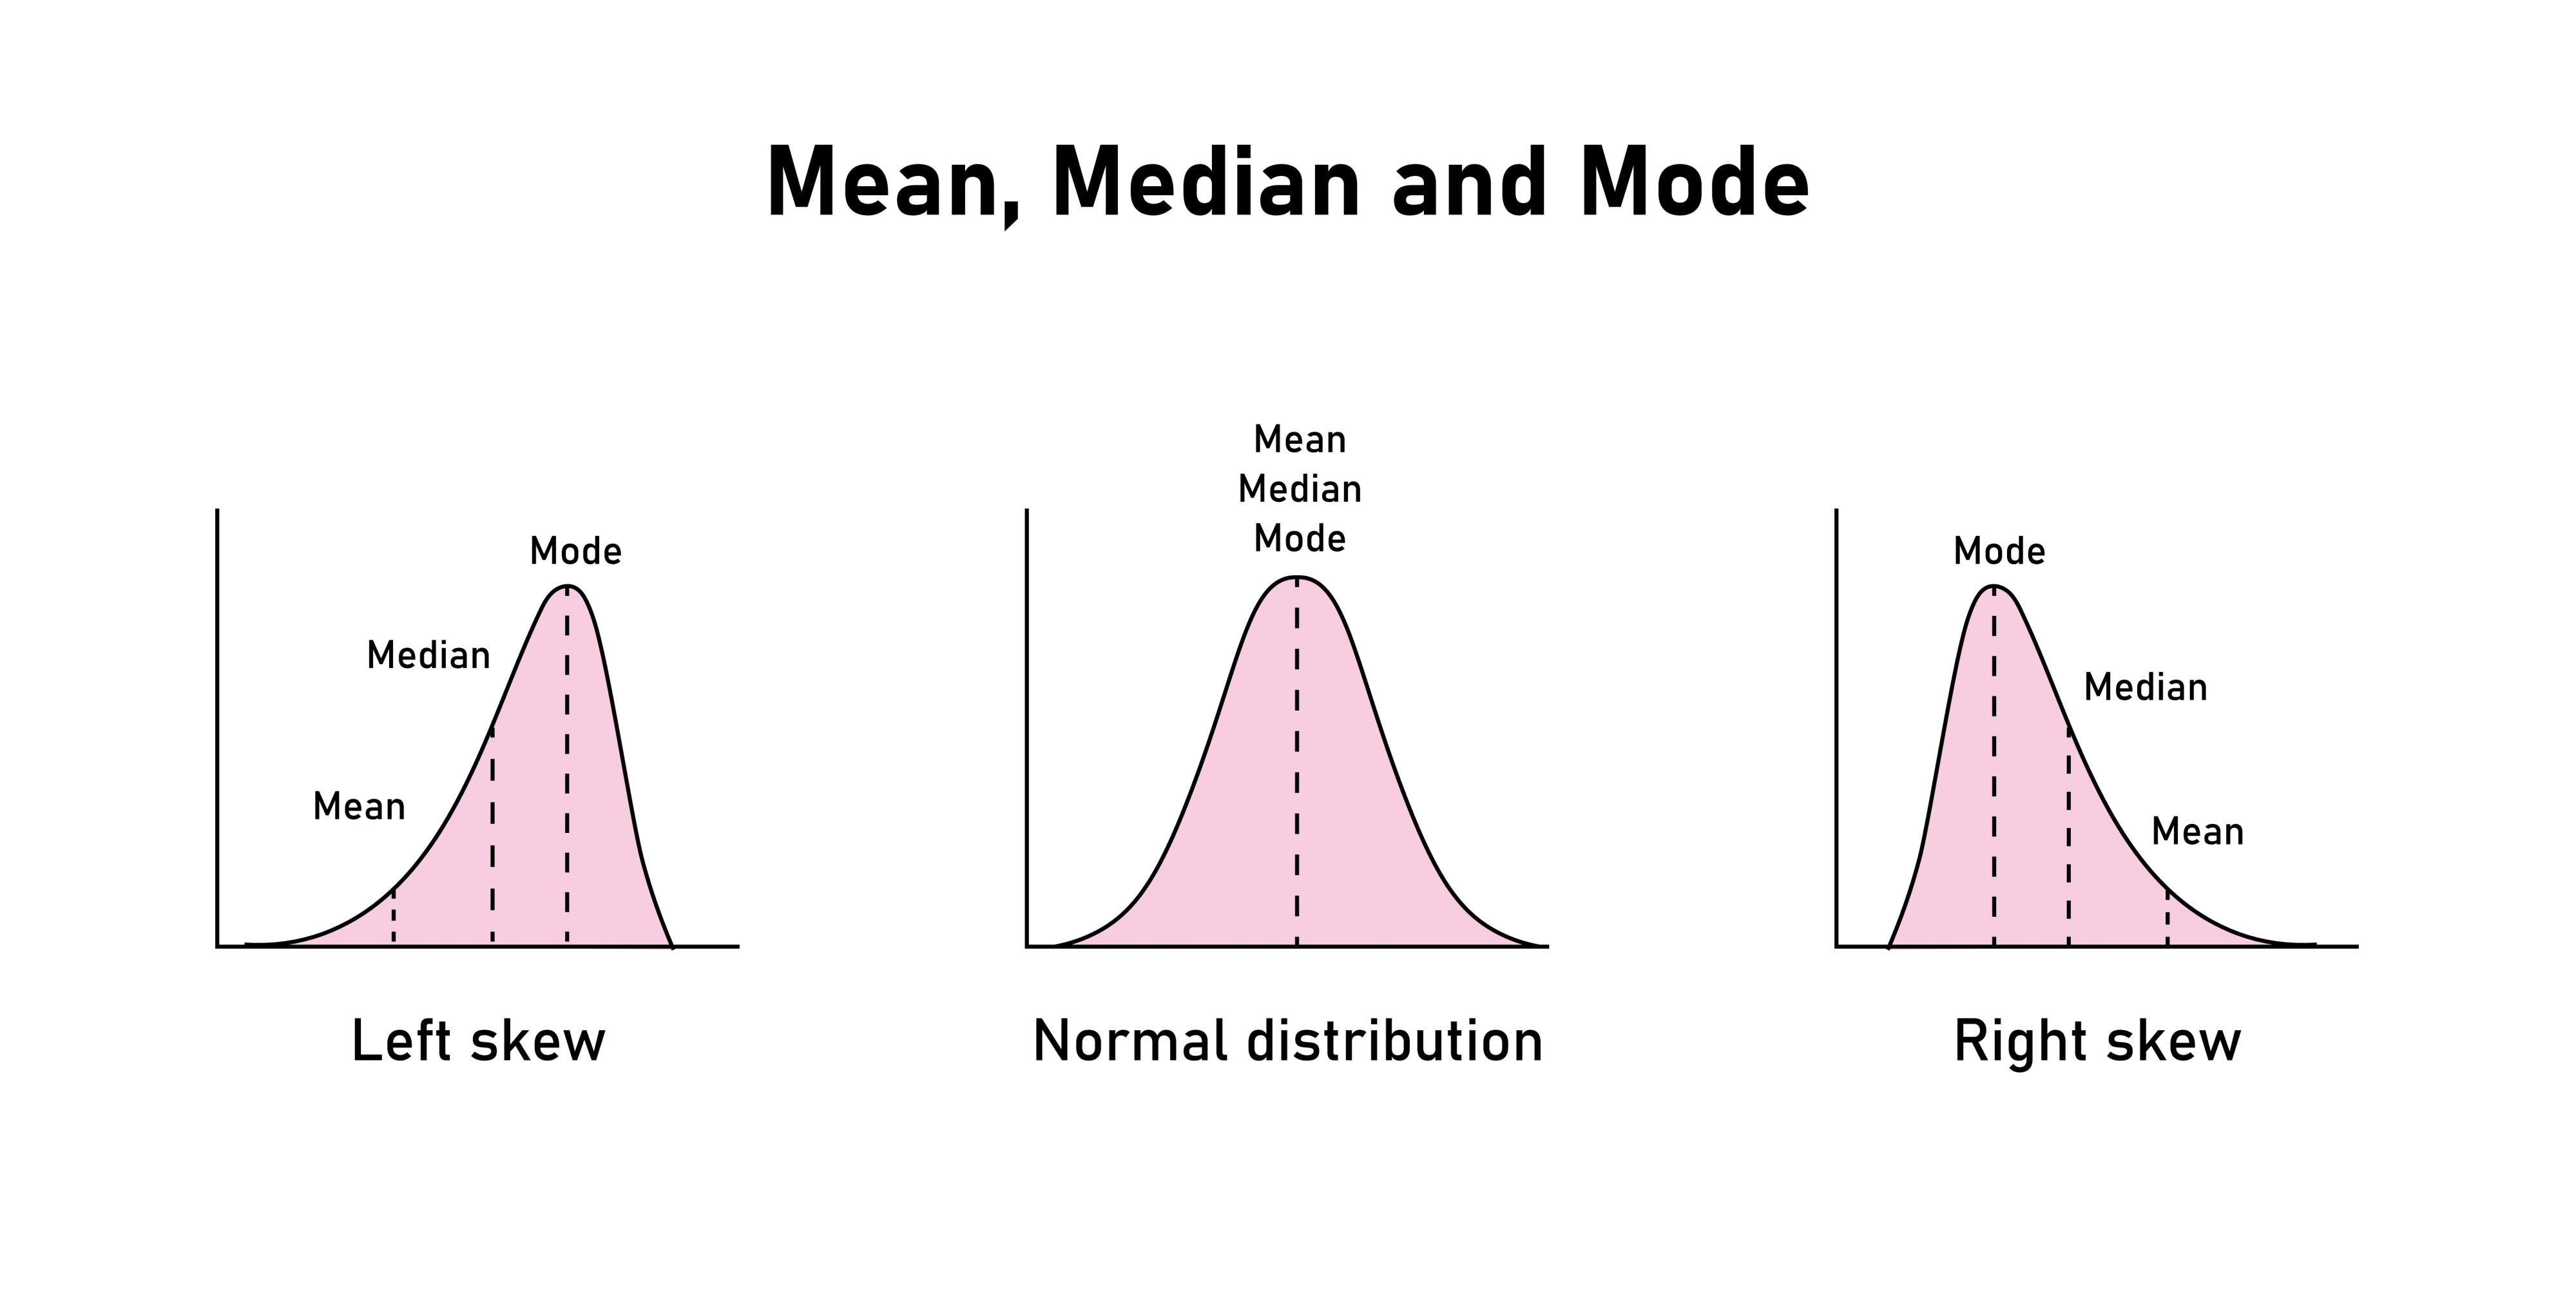

In [33]:
from IPython.display import Image, display
display(Image(filename='skew_image.jpg'))

$$G_1 = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n} \left( \frac{x_i - \bar{x}}{s} \right)^3$$

### 📊 Interprétation du Coefficient d'Asymétrie (Skewness)

Le coefficient d'asymétrie ($G_1$) est un indicateur statistique fondamental lors de la phase d'exploration et de nettoyage des données (ETL). Il permet d'analyser la forme de la distribution d'une variable quantitative par rapport à sa moyenne et de guider scientifiquement nos choix d'imputation des valeurs manquantes.

---

#### 1. Asymétrie Positive ($G_1 > 0$) — Distribution étalée vers la droite
* **Phénomène :** La grande majorité des observations sont regroupées vers les valeurs faibles (à gauche). La "queue" de la distribution s'étire vers la droite à cause d'une poignée de valeurs exceptionnellement élevées (*outliers*).
* **Cas concret du projet (`ACCT_BALANCE` | Skew = 21.67) :** La majeure partie des clients possède un solde bancaire faible ou standard, tandis qu'un très petit groupe de clients fortunés affiche des soldes extrêmement élevés, ce qui tire artificiellement la moyenne vers le haut.
* **Impact ETL / Décision métier :** **Interdiction d'imputer par la moyenne.** Remplacer les vides par une moyenne biaisée créerait de "faux riches". La distribution étant trop hétérogène, la décision rigoureuse est de **laisser les NaN** pour ne pas déformer la réalité économique de la base.

#### 2. Asymétrie Négative ($G_1 < 0$) — Distribution étalée vers la gauche
* **Phénomène :** La majorité des données sont concentrées vers les valeurs élevées (à droite). La "queue" de la distribution s'étire cette fois vers la gauche en raison de quelques valeurs exceptionnellement basses.
* **Cas concret du projet (`DATE_OF_BIRTH` | Skew = -2.43) :** Le portefeuille de la banque est majoritairement jeune ou d'âge moyen (années de naissance élevées), avec une minorité de clients très âgés nés beaucoup plus tôt (années de naissance faibles).
* **Impact ETL / Décision métier :** Pour contrer l'effet des quelques valeurs très basses de la queue gauche, l'imputation par la **médiane (1978)** est la solution la plus stable et la plus représentative de la population globale.

#### 3. Distribution Symétrique ($G_1 \approx 0$) — Courbe en cloche
* **Phénomène :** Les données se répartissent de manière parfaitement équilibrée de part et d'autre du centre. La moyenne et la médiane sont confondues.
* **Cas concret du projet (`CUST_OPENING_DATE` | Skew $\approx$ 0) :** Le rythme des ouvertures de comptes est stable et homogène à travers le temps.
* **Impact ETL / Décision métier :** L'imputation par la **médiane** (ou la moyenne) est ici totalement sécurisée. Elle permet de boucher les valeurs manquantes sans injecter de distorsion ou de bruit artificiel dans le jeu de données.

In [34]:
# 1. Conversion propre en numérique de nos 3 variables
variables_quanti = ["SALARY", "AMOUNT", "FIXEDRATE"]

for col in variables_quanti:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Affichage du diagnostic (Taux de vides + Skewness)
for col in variables_quanti:
    null_pct = df[col].isna().mean() * 100
    skew_val = df[col].skew()
    print(f"[{col}] Vides : {null_pct:.1f}% | Skew : {skew_val:.2f}")

[SALARY] Vides : 57.8% | Skew : 81.47
[AMOUNT] Vides : 38.2% | Skew : 40.27
[FIXEDRATE] Vides : 87.8% | Skew : -1.05


##### Amount

In [35]:
# Si le produit n'est ni un crédit (LENDING) ni un dépôt (DEPOSITS), le montant structurel est 0
filtre_sans_produit = ~df["PRODUCT_GROUP"].isin(["LENDING", "DEPOSITS"])
df.loc[filtre_sans_produit, "AMOUNT"] = df.loc[filtre_sans_produit, "AMOUNT"].fillna(0)

##### Le taux (fixed rate)

In [36]:
# Pour les comptes courants, le taux d'intérêt est de 0%
df.loc[df["PRODUCT_GROUP"] == "ACCOUNTS", "FIXEDRATE"] = df.loc[df["PRODUCT_GROUP"] == "ACCOUNTS", "FIXEDRATE"].fillna(0)

In [37]:
# Remplacement de tous les NaN restants par 0 (clients sans produit ou non rémunérés)
df['FIXEDRATE'] = df['FIXEDRATE'].fillna(0)

print(f"✅ Valeurs manquantes restantes dans FIXEDRATE : {df['FIXEDRATE'].isna().sum()}")

✅ Valeurs manquantes restantes dans FIXEDRATE : 0


##### Maturity date 
Format : Le format hérité CYYMMDD (Century-Year-Month-Day), typique des vieux systèmes bancaires des années 90/2000 (comme les serveurs IBM AS400).

Comment ça marche ? * Le 1 au début est le code pour le XXIe siècle (les années 2000).

Les deux chiffres suivants = l'année.

Les quatre derniers = le mois et le jour.

Exemple : 1160930 ➡️ Siècle 2000 + Année 16 + Mois 09 + Jour 30 ➡️ 30 Septembre 2016.

Exemple : 1110228 ➡️ 28 Février 2011.

In [38]:
# 1. Sécurisation : On convertit en texte et on élimine les ".0" si Python a lu des floats
dates_en_texte = df["MATURITYDATE"].astype(str).str.split(".").str[0]

# 2. Traitement du format à 7 chiffres (CYYMMDD -> ex: 1160930 devient 20160930)
# Si le texte fait 7 caractères et commence par '1', on supprime le '1' et on met '20' à la place
condition_7_chiffres = (dates_en_texte.str.len() == 7) & (
    dates_en_texte.str.startswith("1")
)
dates_harmonisees = np.where(
    condition_7_chiffres, "20" + dates_en_texte.str[1:], dates_en_texte
)

# 3. Conversion magique en VRAIES DATES de type Datetime
# Grâce à errors='coerce', la valeur aberrante '-19000000', les '0' et les 'NaN'
# ne correspondant à aucune date valide vont devenir des 'NaT' (Sans Date).
df["MATURITYDATE"] = pd.to_datetime(
    dates_harmonisees, format="%Y%m%d", errors="coerce"
)

# 4. Vérification et bilan du nettoyage
vides_finaux = df["MATURITYDATE"].isna().sum()
print("🏁 BILAN DU TRAITEMENT DE MATURITYDATE :")
print("=================================================================")
print(f"✅ Colonne convertie avec succès au format : {df['MATURITYDATE'].dtype}")
print(
    f"ℹ️ Nombre de lignes identifiées comme 'SANS DATE' (Futurs NULL SQL) : {vides_finaux}"
)
print("-----------------------------------------------------------------")
print("\n📊 Aperçu des premières vraies dates générées :")
print(df["MATURITYDATE"].dropna().head(10))

🏁 BILAN DU TRAITEMENT DE MATURITYDATE :
✅ Colonne convertie avec succès au format : datetime64[us]
ℹ️ Nombre de lignes identifiées comme 'SANS DATE' (Futurs NULL SQL) : 391520
-----------------------------------------------------------------

📊 Aperçu des premières vraies dates générées :
0    2029-06-27
2    2038-05-27
5    2025-12-31
8    2026-04-02
9    2029-11-27
12   2029-08-27
13   2029-04-27
14   2031-02-06
15   2029-07-27
16   2028-12-27
Name: MATURITYDATE, dtype: datetime64[us]


###  VÉRIFICATION FINALE DE TOUTES LES VARIABLES QUANTITATIVES 

In [39]:
# --- SCRIPT DE CONTRÔLE FINAL : BILAN DE LA QUALITÉ DES DONNÉES (CORRIGÉ V2) ---

# 1. Liste blanche complète des colonnes autorisées à conserver des NaN / NaT (Décisions Validées)
colonnes_tolerees = [
    "SALARY",
    "ACCT_BALANCE",
    "ACCT_OPENING_DATE",
    "ACCT_CLOSE_DATE",
    "STARTDATE",
    "MATURITYDATE",
]

# 2. Calcul des valeurs manquantes (isna() capture à la fois les NaN et les NaT)
vides_par_colonne = df.isna().sum()

# 3. Isolation des colonnes en anomalie (qui ont des vides non prévus)
vides_non_planifies = vides_par_colonne.drop(
    labels=colonnes_tolerees, errors="ignore"
)
vides_non_planifies = vides_non_planifies[vides_non_planifies > 0]

# 4. Affichage du Tableau de Bord de Validation ETL
print(
    "🏁 BILAN DU NETTOYAGE DES VARIABLES QUANTITATIVES, QUALITATIVES & TEMPORELLES :"
)
print("=================================================================")

if len(vides_non_planifies) == 0:
    print(
        "🎉 TOUT EST PARFAIT ! Toutes les valeurs manquantes restantes sont justifiées."
    )
    print("🚀 Le DataFrame est officiellement prêt à être injecté dans PostgreSQL !")
else:
    print(
        f"⚠️ Attention : Il reste des valeurs manquantes non planifiées ({vides_non_planifies.sum()} vides) :"
    )
    print("-----------------------------------------------------------------")
    print(vides_non_planifies)
    print("-----------------------------------------------------------------")
    print(
        "💡 Rappel : Corrigez ces variables spécifiques avant de lancer l'export."
    )

print("=================================================================")
print("📊 RAPPEL DES DÉCISIONS BUSINESS ANALYTICS (NaN / NaT Conservés) :")
print("-----------------------------------------------------------------")
for col in colonnes_tolerees:
    if col in df.columns:
        print(
            f" 📌 La colonne '{col:<19}' conserve ses {df[col].isna().sum():>6} vides (NaN/NaT)."
        )

print("\n💡 Justifications Méthodologiques pour l'Oral :")
print(
    "   • SALARY & ACCT_BALANCE : Distributions asymétriques préservées pour éviter"
)
print("     un biais d'imputation artificiel avant modélisation.")
print(
    "   • ACCT_CLOSE_DATE       : Les valeurs NaT indiquent structurellement"
)
print("     les comptes clients toujours actifs.")
print(
    "   • MATURITYDATE & DATES  : Les valeurs NaT correspondent aux comptes sans"
)
print("     échéance fixe (ex: comptes de dépôt / comptes courants).")
print("=================================================================")

🏁 BILAN DU NETTOYAGE DES VARIABLES QUANTITATIVES, QUALITATIVES & TEMPORELLES :
🎉 TOUT EST PARFAIT ! Toutes les valeurs manquantes restantes sont justifiées.
🚀 Le DataFrame est officiellement prêt à être injecté dans PostgreSQL !
📊 RAPPEL DES DÉCISIONS BUSINESS ANALYTICS (NaN / NaT Conservés) :
-----------------------------------------------------------------
 📌 La colonne 'SALARY             ' conserve ses 257508 vides (NaN/NaT).
 📌 La colonne 'ACCT_BALANCE       ' conserve ses 100485 vides (NaN/NaT).
 📌 La colonne 'ACCT_OPENING_DATE  ' conserve ses 100485 vides (NaN/NaT).
 📌 La colonne 'ACCT_CLOSE_DATE    ' conserve ses 262317 vides (NaN/NaT).
 📌 La colonne 'STARTDATE          ' conserve ses 397907 vides (NaN/NaT).
 📌 La colonne 'MATURITYDATE       ' conserve ses 391520 vides (NaN/NaT).

💡 Justifications Méthodologiques pour l'Oral :
   • SALARY & ACCT_BALANCE : Distributions asymétriques préservées pour éviter
     un biais d'imputation artificiel avant modélisation.
   • ACCT_CLOSE_

In [40]:
"""
from sqlalchemy import create_engine
import time

# 1. Paramètres de connexion à ta base
utilisateur = 'postgres'        
mot_de_passe = 'postgres' 
hote = 'localhost'                # Ton PC local
port = '5432'                     # Port par défaut
nom_bdd = 'PIProject'             # Le nom de ta base

# Création du moteur de connexion
chaine_connexion = f'postgresql+psycopg2://{utilisateur}:{mot_de_passe}@{hote}:{port}/{nom_bdd}'
engine = create_engine(chaine_connexion)

print("Connexion à PIProject établie. Début du transfert...")
debut = time.time()

# 2. Envoi du DataFrame (que l'on suppose s'appeler 'df') vers Postgres
df.to_sql(
    name='data_churn_transformed',    # Le nom de la table qui sera créée automatiquement dans ta base
    con=engine,                # Le moteur de connexion
    if_exists='replace',       # 'replace' pour écraser et recréer la table si tu relances la cellule
    index=False,               # On ne stocke pas l'index technique de Pandas (0, 1, 2...)
    chunksize=10000            # Taille des paquets envoyés
)

fin = time.time()
print(f"Transfert terminé avec succès en {round(fin - debut, 2)} secondes !") 
"""

'\nfrom sqlalchemy import create_engine\nimport time\n\n# 1. Paramètres de connexion à ta base\nutilisateur = \'postgres\'        \nmot_de_passe = \'postgres\' \nhote = \'localhost\'                # Ton PC local\nport = \'5432\'                     # Port par défaut\nnom_bdd = \'PIProject\'             # Le nom de ta base\n\n# Création du moteur de connexion\nchaine_connexion = f\'postgresql+psycopg2://{utilisateur}:{mot_de_passe}@{hote}:{port}/{nom_bdd}\'\nengine = create_engine(chaine_connexion)\n\nprint("Connexion à PIProject établie. Début du transfert...")\ndebut = time.time()\n\n# 2. Envoi du DataFrame (que l\'on suppose s\'appeler \'df\') vers Postgres\ndf.to_sql(\n    name=\'data_churn_transformed\',    # Le nom de la table qui sera créée automatiquement dans ta base\n    con=engine,                # Le moteur de connexion\n    if_exists=\'replace\',       # \'replace\' pour écraser et recréer la table si tu relances la cellule\n    index=False,               # On ne stocke pa

# Jointures avec les tables de dimensions

###  1. Dimension Clients

In [62]:

dim_client = df.drop_duplicates(subset='CUSTOMER_NO').copy()

# --- Âge (KPI 03) ---
# Logique métier : âge = année courante - année de naissance.
# On filtre les valeurs aberrantes (ex: âge négatif ou >100 ans dû à
# une erreur de saisie) pour ne pas fausser la segmentation Power BI.
dim_client['age'] = 2026 - dim_client['DATE_OF_BIRTH'].dt.year
dim_client['age'] = dim_client['age'].where(dim_client['age'].between(0, 100))

bins = [0 ,18, 30, 40, 50, 60, 100]
labels = ['<18', '18-30', '31-40', '41-50', '51-60', '60+']
dim_client['age_group'] = pd.cut(dim_client['age'], bins=bins, labels=labels)

# --- Ancienneté client (KPI 02) ---
# Logique métier : nombre d'années depuis l'ouverture de la relation
# client (et non du compte -> CUST_OPENING_DATE, pas ACCT_OPENING_DATE).
dim_client['tenure_years'] = 2026 - dim_client['CUST_OPENING_DATE'].dt.year

# --- Risque KYC encodé (KPI 08) ---
# Logique métier : SCORE_KYC est une variable catégorielle ORDONNÉE
# (LR = risque faible -> H3 = risque très élevé). On l'encode en
# ordinal plutôt qu'en one-hot, car l'ordre porte une information
# métier (H3 est "pire" que H1, pas juste "différent").
kyc_map = {'LR': 0, 'MR': 1, 'H1': 2, 'H2': 3, 'H3': 4}
dim_client['kyc_risk'] = dim_client['SCORE_KYC'].map(kyc_map)

# --- Dossier complet (KPI 10) ---
# Logique métier : COMPLETED_FILE vaut 'YES' ou est manquant (NaN).
# On normalise en flag binaire 1/0, plus facile à filtrer/agréger
# dans Power BI qu'un texte avec des valeurs nulles.
dim_client['file_ok'] = (dim_client['COMPLETED_FILE'] == 'YES').astype(int)

# --- Sélection finale des colonnes de la dimension ---
dim_client = dim_client[[
    'CUSTOMER_NO', 'MARITAL_STATUS', 'NATURE_CLIENT', 'PARTYCLASS',
    'DATE_OF_BIRTH', 'age', 'age_group',
    'CUST_OPENING_DATE', 'tenure_years',
    'SCORE_KYC', 'kyc_risk', 'file_ok',
    'BRANCH', 'LOB'
]].reset_index(drop=True)

print(f"DIM_CLIENT construite : {len(dim_client):,} clients uniques")
print(dim_client.head(3).to_string()) 


DIM_CLIENT construite : 319,129 clients uniques
  CUSTOMER_NO MARITAL_STATUS NATURE_CLIENT PARTYCLASS DATE_OF_BIRTH  age age_group CUST_OPENING_DATE  tenure_years SCORE_KYC  kyc_risk  file_ok BRANCH  LOB
0     C318650              M           PPH     Retail    1969-01-01   57     51-60        2004-09-30            22        LR         0        1  BR114    4
1     C318648              M           PPH     Retail    1960-01-01   66       60+        2004-09-30            22        LR         0        1  BR114    4
2     C318644              M           PPH     Retail    1961-01-01   65       60+        2004-09-30            22        LR         0        1  BR114    4


In [63]:
from sqlalchemy import create_engine, text
DB_USER = "postgres"          # Ton utilisateur
DB_PASSWORD = "postgres"      # Ton mot de passe
DB_HOST = "localhost"         # L'adresse de ton serveur
DB_PORT = "5432"              # Le port par défaut
DB_NAME = "PIProject"          # Le nom de ton Data Warehouse

# Création de la connexion (Engine)
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')


# ==========================================
# 3. CHARGEMENT DANS POSTGRESQL & CLÉ PRIMAIRE
# ==========================================

table_name = "dim_client"
print(f"\n🚀 Initialisation du chargement de {len(dim_client):,} clients dans PostgreSQL...")

try:
    # Envoi du DataFrame vers Postgres
    dim_client.to_sql(
        name=table_name,
        con=engine,
        if_exists='replace',  # Écrase et recrée la table proprement à chaque run
        index=False,          # N'importe pas l'index séquentiel de Pandas
        chunksize=10000,      # Optimisation de la mémoire par blocs de 10k lignes
        method='multi'        # Accélère l'insertion groupée
    )
    print(f"✅ Données transférées avec succès dans la table '{table_name}'.")

    # --- CORRECTION ICI : Ajout de la Clé Primaire avec doubles guillemets ---
    # Les doubles guillemets "CUSTOMER_NO" forcent Postgres à respecter les majuscules créées par Pandas
    with engine.connect() as connection:
        connection.execute(text(f'ALTER TABLE {table_name} ADD PRIMARY KEY ("CUSTOMER_NO");'))
        connection.commit()
        
    print(f"🔑 Contrainte PK appliquée avec succès : 'CUSTOMER_NO' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Une erreur est survenue lors du chargement : \n{e}")


🚀 Initialisation du chargement de 319,129 clients dans PostgreSQL...
✅ Données transférées avec succès dans la table 'dim_client'.
🔑 Contrainte PK appliquée avec succès : 'CUSTOMER_NO' est la Clé Primaire officielle.


### Dimension Produits

In [59]:
# ─────────────────────────────────────────────
# 1. CONSTRUCTION DE LA DIMENSION
# ─────────────────────────────────────────────

# Le grain de DIM_PRODUCT est le produit unique.
# On dédoublonne sur PRODUCT (libellé fin du produit),
# car c'est la clé naturelle la plus granulaire dans le fichier source.
# PRODUCT_LINE et PRODUCT_GROUP sont des attributs hiérarchiques stables
# d'un même produit → ils ne changent pas d'un client à l'autre.
dim_product = df.drop_duplicates(subset='PRODUCT').copy()

# --- Indicateur dépôt à terme (KPI 07) ---
# Logique métier : les dépôts à terme churned à 96% à l'échéance.
# On isole cette famille via PRODUCT_LINE == 'DEPOSITS' pour permettre
# à Power BI de la filtrer directement sans taper sur la chaîne de texte.
dim_product['is_term_deposit'] = (
    dim_product['PRODUCT_LINE'].str.upper() == 'DEPOSITS'
).astype(int)

# --- Produit arrivé à échéance (KPI 07) ---
# Logique métier : un produit dont MATURITYDATE est dépassée génère un
# churn structurel (fin de contrat), distinct du churn volontaire.
# Ce flag permet de l'exclure des modèles ML si besoin, ou de le pondérer
# différemment dans Power BI.
today = pd.Timestamp('2026-01-01')   # date de référence cohérente avec le dataset
 
# Forcer le cast en datetime64 pour éviter le TypeError
# (cas où la colonne contient des objets numpy.ndarray ou des strings résiduelles)
dim_product['MATURITYDATE'] = pd.to_datetime(
    dim_product['MATURITYDATE'], errors='coerce'
)
 
dim_product['is_matured'] = (
    dim_product['MATURITYDATE'].notna() &
    (dim_product['MATURITYDATE'] < today)
).astype(int)

# --- Encodage ordinal de la ligne produit (KPI 07) ---
# Logique métier : PRODUCT_LINE suit une logique de risque de churn croissant
# (ACCOUNTS 13.9% → LENDING 59.4% → DEPOSITS 96.2%).
# L'encodage ordinal permet au modèle ML de capturer cet ordre naturel,
# contrairement à un one-hot qui traiterait les catégories comme équivalentes.
product_line_risk_map = {
    'ACCOUNTS':         0,
    'SAFE.DEPOSIT.BOX': 1,
    'LENDING':          2,
    'DEPOSITS':         3,
}
dim_product['product_line_risk'] = (
    dim_product['PRODUCT_LINE'].map(product_line_risk_map)
)

# --- Sélection initiale des colonnes de la dimension ---
dim_product = dim_product[[
    'PRODUCT_GROUP',
    'PRODUCT_LINE',    'product_line_risk',
    'PRODUCT',
    'ACCOUNTNATURE',
    'FIXEDRATE',
    'STARTDATE',       'MATURITYDATE',    'is_matured',
    'PRODUCT_STATUS',
    'AMOUNT',
    'is_term_deposit',
]].reset_index(drop=True)

# ✨ CHANGEMENT : Génération de la clé de substitution textuelle (Format PROD_001)
dim_product['product_key'] = 'PROD_' + (dim_product.index + 1).astype(str).str.zfill(3)

# Réorganisation pour placer la clé primaire (PK) en première colonne
dim_product = dim_product[[
    'product_key',
    'PRODUCT_GROUP',
    'PRODUCT_LINE',    'product_line_risk',
    'PRODUCT',
    'ACCOUNTNATURE',
    'FIXEDRATE',
    'STARTDATE',       'MATURITYDATE',    'is_matured',
    'PRODUCT_STATUS',
    'AMOUNT',
    'is_term_deposit'
]]

print(f"DIM_PRODUCT construite : {len(dim_product):,} produits uniques")
print(dim_product.head(3).to_string())


# ─────────────────────────────────────────────
# 2. CONNEXION POSTGRESQL
# ─────────────────────────────────────────────
DB_USER     = "postgres"
DB_PASSWORD = "postgres"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "PIProject"

engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# ─────────────────────────────────────────────
# 3. CHARGEMENT DANS POSTGRESQL & CLÉ PRIMAIRE
# ─────────────────────────────────────────────
table_name = "dim_product"
print(f"\n🚀 Chargement de {len(dim_product):,} produits dans PostgreSQL...")

try:
    # CHANGEMENT : index=False car 'product_key' est maintenant une colonne explicite
    dim_product.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',      # Recrée la table proprement à chaque run
        index       = False,          # Modifié
        chunksize   = 10000,
        method      = 'multi'
    )
    print(f"✅ Données transférées avec succès dans la table '{table_name}'.")

    # Ajout de la clé primaire sur product_key
    # Les doubles guillemets forcent Postgres à respecter la casse de Pandas
    with engine.connect() as connection:
        connection.execute(text(
            f'ALTER TABLE {table_name} ADD PRIMARY KEY ("product_key");'
        ))
        connection.commit()

    print(f"🔑 Contrainte PK appliquée : 'product_key' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Erreur lors du chargement :\n{e}")

DIM_PRODUCT construite : 226 produits uniques
  product_key       PRODUCT_GROUP PRODUCT_LINE  product_line_risk                   PRODUCT                      ACCOUNTNATURE  FIXEDRATE  STARTDATE MATURITYDATE  is_matured PRODUCT_STATUS       AMOUNT  is_term_deposit
0    PROD_001   RT.CRD.IMMOBILERS      LENDING               2.00  RT.RT.CRD.IMMOBILERS.527  Crédit acquisition logement TEGF6       4.50 1251-02-27   2029-06-27           0        CURRENT  10954600.00                0
1    PROD_002  BANK.PLACEMENT.NEG     DEPOSITS               3.00          BANK.CAT.NEG.SIM                     DEPOTS A TERME       0.00 2026-01-02          NaT           0         UNAUTH         0.00                1
2    PROD_003   RT.CRD.IMMOBILERS      LENDING               2.00  RT.RT.CRD.IMMOBILERS.548                  Crédit rénovation       4.50 1251-02-27   2038-05-27           0        CURRENT 113593077.00                0

🚀 Chargement de 226 produits dans PostgreSQL...
✅ Données transférées avec su

### Dimension account

In [58]:
# ─────────────────────────────────────────────
# 1. CONSTRUCTION DE LA DIMENSION
# ─────────────────────────────────────────────

# Le grain de DIM_ACCOUNT est le compte unique.
# On dédoublonne sur ACCOUNT_NO (numéro de compte),
# clé naturelle du compte bancaire dans le fichier source.
dim_account = df.drop_duplicates(subset='ACCOUNT_NO').copy()

# --- Variable cible binaire (Y) ---
dim_account['churn'] = (
    dim_account['ACCOUNT_STATUS'] == 'Closed'
).astype(int)

# --- Ancienneté du compte en jours (KPI 02 côté compte) ---
ref_date = pd.Timestamp('2027-01-01')
"""
dim_account['ACCT_OPENING_DATE'] = pd.to_datetime(
    dim_account['ACCT_OPENING_DATE'], errors='coerce'
)
dim_account['ACCT_CLOSE_DATE'] = pd.to_datetime(
    dim_account['ACCT_CLOSE_DATE'], errors='coerce'
)
"""
end_date = dim_account['ACCT_CLOSE_DATE'].fillna(ref_date)
dim_account['acct_tenure_days'] = (
    end_date - dim_account['ACCT_OPENING_DATE']
).dt.days

# Valeurs négatives ou aberrantes → NaN (erreur de saisie)
dim_account['acct_tenure_days'] = dim_account['acct_tenure_days'].where(
    dim_account['acct_tenure_days'] >= 0
)

# --- Nombre de comptes par client ---
nb_accounts = (
    df.groupby('CUSTOMER_NO')['ACCOUNT_NO']
    .nunique()
    .rename('nb_accounts_per_client')
)
dim_account = dim_account.merge(nb_accounts, on='CUSTOMER_NO', how='left')

# --- Date de prochaine révision ---
dim_account['NEXT__REVIEW_DATE'] = pd.to_datetime(
    dim_account['NEXT__REVIEW_DATE'], errors='coerce'
)

# --- Sélection initiale des colonnes de la dimension ---
dim_account = dim_account[[
    'ACCOUNT_NO',
    'ACCOUNT_STATUS',    'churn',
    'ACCOUNT_CATEGORY',
    'ACCOUNT_TYPE_DESC',
    'CURRENCY',
    'ACCT_OPENING_DATE', 'ACCT_CLOSE_DATE',
    'acct_tenure_days',
    'nb_accounts_per_client',
]].reset_index(drop=True)

# ✨ CHANGEMENT : Génération de la clé de substitution textuelle (Format ACC_000001)
dim_account['account_key'] = 'ACC_' + (dim_account.index + 1).astype(str).str.zfill(6)

# Réorganisation pour placer la clé primaire (PK) en première colonne
dim_account = dim_account[[
    'account_key',
    'ACCOUNT_NO',
    'ACCOUNT_STATUS',    'churn',
    'ACCOUNT_CATEGORY',
    'ACCOUNT_TYPE_DESC',
    'CURRENCY',
    'ACCT_OPENING_DATE', 'ACCT_CLOSE_DATE',
    'acct_tenure_days',
    'nb_accounts_per_client'
]]

print(f"DIM_ACCOUNT construite : {len(dim_account):,} comptes uniques")
print(dim_account.head(3).to_string())


# ─────────────────────────────────────────────
# 2. CONNEXION POSTGRESQL
# ─────────────────────────────────────────────
DB_USER     = "postgres"
DB_PASSWORD = "postgres"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "PIProject"

engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# ─────────────────────────────────────────────
# 3. CHARGEMENT DANS POSTGRESQL & CLÉ PRIMAIRE
# ─────────────────────────────────────────────
table_name = "dim_account"
print(f"\n🚀 Chargement de {len(dim_account):,} comptes dans PostgreSQL...")

try:
    # CHANGEMENT : index=False car 'account_key' est maintenant une colonne explicite
    dim_account.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',      # Recrée la table proprement à chaque run
        index       = False,          # Modifié
        chunksize   = 10000,
        method      = 'multi'
    )
    print(f"✅ Données transférées avec succès dans la table '{table_name}'.")

    with engine.connect() as connection:
        connection.execute(text(
            f'ALTER TABLE {table_name} ADD PRIMARY KEY ("account_key");'
        ))
        connection.commit()

    print(f"🔑 Contrainte PK appliquée : 'account_key' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Erreur lors du chargement :\n{e}")

DIM_ACCOUNT construite : 410,587 comptes uniques
  account_key ACCOUNT_NO ACCOUNT_STATUS  churn  ACCOUNT_CATEGORY                  ACCOUNT_TYPE_DESC CURRENCY ACCT_OPENING_DATE ACCT_CLOSE_DATE  acct_tenure_days  nb_accounts_per_client
0  ACC_000001   A0365322         Closed      1           3023.00  Crédit acquisition logement TEGF6      TND        2019-08-27      2026-01-28           2346.00                       4
1  ACC_000002   A0373555         Closed      1           3611.00                     DEPOTS A TERME      TND        2026-01-05      2025-06-30               NaN                       6
2  ACC_000003   A0348290         Closed      1           3017.00                  Crédit rénovation      TND        2023-06-12      2026-01-28            961.00                       4

🚀 Chargement de 410,587 comptes dans PostgreSQL...
✅ Données transférées avec succès dans la table 'dim_account'.


KeyboardInterrupt: 

In [47]:
df.head()

,CUSTOMER_NO,ACCOUNT_NO,NATIONALITY,RESIDENCE,MARITAL_STATUS,CUST_OPENING_DATE,DATE_OF_BIRTH,NATURE_CLIENT,BRANCH,SCORE_KYC,COMPLETED_FILE,LAST_REVIEW_DATE,NEXT__REVIEW_DATE,ACCOUNT_STATUS,ACCT_OPENING_DATE,ACCOUNT_CATEGORY,ACCOUNT_TYPE_DESC,CURRENCY,ACCT_CLOSE_DATE,CLOSURE_REASON,ACCT_BALANCE,INDUSTRY,SALARY,PRODUCT_GROUP,PRODUCT_LINE,PRODUCT,ACCOUNTNATURE,STARTDATE,MATURITYDATE,AMOUNT,FIXEDRATE,PRODUCT_STATUS,PARTYCLASS,LOB
0,C318650,A0365322,TN,TN,M,2004-09-30,1969-01-01,PPH,BR114,LR,YES,2025-09-05,2029-09-05,Closed,2019-08-27,3023.00,Crédit acquisition logement TEGF6,TND,2026-01-28,INCONNUE,-10714.35,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.527,Crédit acquisition logement TEGF6,1251-02-27,2029-06-27,10954600.00,4.50,CURRENT,Retail,4
1,C318648,A0373555,TN,TN,M,2004-09-30,1960-01-01,PPH,BR114,LR,YES,2025-09-05,2029-09-05,Closed,2026-01-05,3611.00,DEPOTS A TERME,TND,2025-06-30,INCONNUE,0.00,9000,3300.54,BANK.PLACEMENT.NEG,DEPOSITS,BANK.CAT.NEG.SIM,DEPOTS A TERME,2026-01-02,NaT,0.00,0.00,UNAUTH,Retail,4
2,C318650,A0348290,TN,TN,M,2004-09-30,1969-01-01,PPH,BR114,LR,YES,2025-09-05,2029-09-05,Closed,2023-06-12,3017.00,Crédit rénovation,TND,2026-01-28,INCONNUE,-113033.10,9000,2725.74,RT.CRD.IMMOBILERS,LENDING,RT.RT.CRD.IMMOBILERS.548,Crédit rénovation,1251-02-27,2038-05-27,113593077.00,4.50,CURRENT,Retail,4
3,C318650,A0257995,TN,TN,M,2004-09-30,1969-01-01,PPH,BR114,LR,YES,2025-09-05,2029-09-05,Closed,2022-05-27,1011.00,Compte Allocation Touristique TND,TND,2026-01-28,INCONNUE,0.00,9000,2725.74,BANK.GRP.CUR.ACCT,ACCOUNTS,BANK.CUR.ACCT.ALL.TOURS.CARTE,Compte Allocation Touristique TND,NaT,NaT,0.00,0.00,NON_APPLICABLE,Retail,4
4,C318648,A0312991,TN,TN,M,2004-09-30,1960-01-01,PPH,BR114,LR,YES,2025-09-05,2029-09-05,Closed,2025-07-02,3611.00,DEPOTS A TERME,TND,2025-06-30,INCONNUE,0.00,9000,3300.54,SANS_PRODUIT,SANS_LIGNE,NULL,DEPOTS A TERME,NaT,NaT,0.00,0.00,NON_APPLICABLE,Retail,4


### Dimension Branch

In [57]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text

# ─────────────────────────────────────────────
# 1. CONSTRUCTION DE LA DIMENSION
# ─────────────────────────────────────────────

# Le grain de DIM_BRANCH est l'agence unique.
# On dédoublonne sur BRANCH (code agence),
# clé naturelle de l'agence dans le fichier source.
dim_branch = df.drop_duplicates(subset='BRANCH').copy()

"""
# --- Label lisible de l'agence ---
if 'branch_label' not in dim_branch.columns:
    dim_branch['branch_label'] = dim_branch['BRANCH'].str.strip().str.title() 
"""
"""
# --- Région ---
if 'region' not in dim_branch.columns:
    print("⚠️  Colonne 'region' absente du fichier source → créée vide.")
    print("   À enrichir via le référentiel agences de la banque.")
    dim_branch['region'] = None 
"""

# --- Nettoyage des chaînes ---
for col in ['BRANCH', 'LOB', 'PARTYCLASS']:
    if col in dim_branch.columns:
        dim_branch[col] = (
            dim_branch[col]
            .astype(str)
            .str.strip()
            .replace('nan', None)
        )

# --- Contrôle qualité ---
nb_null_branch = dim_branch['BRANCH'].isna().sum()
if nb_null_branch > 0:
    print(f"⚠️  {nb_null_branch} agence(s) avec BRANCH null → à investiguer.")
else:
    print("✅ Aucune agence sans code BRANCH.")

# --- Sélection initiale des colonnes du fichier source ---
dim_branch = dim_branch[[
    'BRANCH',
    'LOB',
    'PARTYCLASS',
]].reset_index(drop=True)

# ✨ CHANGEMENT : Génération de la clé de substitution textuelle (Format BR_001)
dim_branch['branch_key'] = 'BR_' + (dim_branch.index + 1).astype(str).str.zfill(3)

# Réorganisation pour placer la clé primaire (PK) en première colonne
dim_branch = dim_branch[['branch_key', 'BRANCH', 'LOB', 'PARTYCLASS']]

print(f"DIM_BRANCH construite : {len(dim_branch):,} agences uniques")
print(dim_branch.head(3).to_string())


# ─────────────────────────────────────────────
# 2. CONNEXION POSTGRESQL
# ─────────────────────────────────────────────
DB_USER     = "postgres"
DB_PASSWORD = "postgres"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "PIProject"

engine = create_engine(
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

# ─────────────────────────────────────────────
# 3. CHARGEMENT DANS POSTGRESQL & CLÉ PRIMAIRE
# ─────────────────────────────────────────────
table_name = "dim_branch"
print(f"\n🚀 Chargement de {len(dim_branch):,} agences dans PostgreSQL...")

try:
    # CHANGEMENT : index=False car 'branch_key' est maintenant une vraie colonne textuelle
    dim_branch.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',
        index       = False,      # Modifié
        chunksize   = 10000,
        method      = 'multi'
    )
    print(f"✅ Données transférées avec succès dans la table '{table_name}'.")

    with engine.connect() as connection:
        connection.execute(text(
            f'ALTER TABLE {table_name} ADD PRIMARY KEY ("branch_key");'
        ))
        connection.commit()

    print(f"🔑 Contrainte PK appliquée : 'branch_key' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Erreur lors du chargement :\n{e}")

✅ Aucune agence sans code BRANCH.
DIM_BRANCH construite : 141 agences uniques
  branch_key BRANCH LOB PARTYCLASS
0     BR_001  BR114   4     Retail
1     BR_002   BR16   4     Retail
2     BR_003   BR47   4     Retail

🚀 Chargement de 141 agences dans PostgreSQL...
✅ Données transférées avec succès dans la table 'dim_branch'.
🔑 Contrainte PK appliquée : 'branch_key' est la Clé Primaire officielle.


### Dimension Closure 

In [56]:

# 3. Extraction de la colonne et suppression des doublons
dim_closure = df[['CLOSURE_REASON']].drop_duplicates().copy()

# 4. Génération de la clé primaire artificielle (Surrogate Key)
dim_closure.reset_index(drop=True, inplace=True)
dim_closure['closure_key'] = 'CLOS_' + (dim_closure.index + 1).astype(str).str.zfill(3)

# 5. Renommer selon les standards de ton Data Warehouse (snake_case)
dim_closure = dim_closure.rename(columns={
    'CLOSURE_REASON': 'closure_reason'
})

# Réorganisation pour placer la clé primaire (PK) en premier
dim_closure = dim_closure[['closure_key', 'closure_reason']]

# 6. Vérification du résultat
print(f"Dimensions de la table dim_CLOSURE : {dim_closure.shape}")
print(dim_closure)

# 3. CHARGEMENT DANS POSTGRESQL & CLÉ PRIMAIRE (DIM_CLOSURE)
# ─────────────────────────────────────────────────────────
table_name = "dim_closure"
print(f"\n🚀 Chargement de {len(dim_closure):,} motifs de clôture dans PostgreSQL...")

try:
    dim_closure.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',
        index       = False,  # False car 'closure_key' est déjà une colonne du DataFrame
        chunksize   = 10000,
        method      = 'multi'
    )
    print(f"✅ Données transférées avec succès dans la table '{table_name}'.")

    with engine.connect() as connection:
        connection.execute(text(
            f'ALTER TABLE {table_name} ADD PRIMARY KEY ("closure_key");'
        ))
        connection.commit()

    print(f"🔑 Contrainte PK appliquée : 'closure_key' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Erreur lors du chargement :\n{e}")

Dimensions de la table dim_CLOSURE : (20, 2)
   closure_key   closure_reason
0     CLOS_001         INCONNUE
1     CLOS_002   BANK.REASON.13
2     CLOS_003    BANK.REASON.9
3     CLOS_004        Non fermé
4     CLOS_005    BANK.REASON.1
5     CLOS_006   BANK.REASON.12
6     CLOS_007   BANK.REASON.10
7     CLOS_008    BANK.REASON.2
8     CLOS_009    BANK.REASON.6
9     CLOS_010    BANK.REASON.3
10    CLOS_011    BANK.REASON.5
11    CLOS_012  BANK.REASON.112
12    CLOS_013  BANK.REASON.100
13    CLOS_014    BANK.REASON.8
14    CLOS_015    BANK.REASON.4
15    CLOS_016   BANK.REASON.11
16    CLOS_017    BANK.REASON.7
17    CLOS_018  BANK.REASON.104
18    CLOS_019  BANK.REASON.109
19    CLOS_020  BANK.REASON.111

🚀 Chargement de 20 motifs de clôture dans PostgreSQL...
✅ Données transférées avec succès dans la table 'dim_closure'.
🔑 Contrainte PK appliquée : 'closure_key' est la Clé Primaire officielle.


### Dimension temps

In [60]:
# ─────────────────────────────────────────────────────────────
# 1. CONSTRUCTION DYNAMIQUE DE LA DIMENSION TEMPS
# ─────────────────────────────────────────────────────────────

# Identification des colonnes sources de dates
date_cols = ['CUST_OPENING_DATE', 'ACCT_OPENING_DATE', 'MATURITYDATE', 'ACCT_CLOSE_DATE']
dates_list = []

for col in date_cols:
    if col in df.columns:
        # Conversion forcée en datetime, les erreurs deviennent NaT (Not a Time)
        dates_list.append(pd.to_datetime(df[col], errors='coerce'))

# Détection de la date la plus ancienne et la plus récente
min_date = pd.concat(dates_list).min()
max_date = pd.Timestamp('2027-01-01') # Date de référence future pour couvrir tout le dataset

print(f"📅 Plage temporelle détectée : de {min_date.date()} à {max_date.date()}")

# Génération de la plage de dates complète
date_range = pd.date_range(start=min_date, end=max_date)
dim_time = pd.DataFrame({'full_date': date_range})

# Extraction des composants
dim_time['day']     = dim_time['full_date'].dt.day
dim_time['month']   = dim_time['full_date'].dt.month
dim_time['year']    = dim_time['full_date'].dt.year
dim_time['quarter'] = dim_time['full_date'].dt.quarter

# ✨ Génération de la clé de substitution (Format TIME_0001)
dim_time.reset_index(drop=True, inplace=True)
dim_time['date_key'] = 'TIME_' + (dim_time.index + 1).astype(str).str.zfill(4)

# Réorganisation pour placer la clé primaire (PK) en premier
dim_time = dim_time[['date_key', 'full_date', 'day', 'month', 'year', 'quarter']]

print(f"✅ DIM_TIME construite : {len(dim_time):,} jours générés.")

# ─────────────────────────────────────────────────────────────
# 2. CHARGEMENT DANS POSTGRESQL
# ─────────────────────────────────────────────────────────────
table_name = "dim_time"
print(f"\n🚀 Chargement de la dimension temps dans PostgreSQL...")

try:
    dim_time.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',
        index       = False,      # False car 'date_key' est une colonne explicite
        chunksize   = 10000,
        method      = 'multi'
    )
    
    with engine.connect() as connection:
        connection.execute(text(
            f'ALTER TABLE {table_name} ADD PRIMARY KEY ("date_key");'
        ))
        connection.commit()

    print(f"🔑 Contrainte PK appliquée : 'date_key' est la Clé Primaire officielle.")

except Exception as e:
    print(f"❌ Erreur lors du chargement :\n{e}")

📅 Plage temporelle détectée : de 1980-01-01 à 2027-01-01
✅ DIM_TIME construite : 17,168 jours générés.

🚀 Chargement de la dimension temps dans PostgreSQL...
🔑 Contrainte PK appliquée : 'date_key' est la Clé Primaire officielle.


### Table des faits

In [67]:
# ─────────────────────────────────────────────────────────────
# 1. CONSTRUCTION DE LA TABLE DES FAITS
# ─────────────────────────────────────────────────────────────
fact_churn = df.copy()

# A. Mapping des clés étrangères
# --- Branche (Surrogate Key) ---
branch_map = dim_branch[['branch_key', 'BRANCH']].set_index('BRANCH')['branch_key']
fact_churn['branch_key'] = fact_churn['BRANCH'].map(branch_map)

# --- Produit (Surrogate Key) ---
product_map = dim_product[['product_key', 'PRODUCT']].set_index('PRODUCT')['product_key']
fact_churn['product_key'] = fact_churn['PRODUCT'].map(product_map)

# --- Client (Clé Métier CUSTOMER_NO) ---
# Ici, on ne fait pas de map vers une surrogate key, 
# on garde directement le CUSTOMER_NO pour la jointure
fact_churn['client_id'] = fact_churn['CUSTOMER_NO'] 

# --- Clôture (Surrogate Key) ---
closure_map = dim_closure[['closure_key', 'closure_reason']].set_index('closure_reason')['closure_key']
fact_churn['closure_reason'] = fact_churn['CLOSURE_REASON'].fillna('Not Applicable (Active Client)')
fact_churn['closure_key'] = fact_churn['closure_reason'].map(closure_map)

# B. Calcul des mesures et nettoyage
fact_churn['churn_flag'] = (fact_churn['ACCOUNT_STATUS'] == 'Closed').astype(int)
fact_churn['is_active'] = (fact_churn['ACCOUNT_STATUS'] == 'Active').astype(int)

# Sélection finale
fact_cols = [
    'client_id', 'product_key', 'branch_key', 'closure_key',
    'churn_flag', 'is_active', 'ACCT_BALANCE', 'SALARY'
]
fact_churn = fact_churn[fact_cols]

# ─────────────────────────────────────────────────────────────
# 2. CHARGEMENT DANS POSTGRESQL
# ─────────────────────────────────────────────────────────────
table_name = "fact_churn"
print(f"\n🚀 Chargement de {len(fact_churn):,} lignes dans la table des faits...")

try:
    fact_churn.to_sql(
        name        = table_name,
        con         = engine,
        if_exists   = 'replace',
        index       = False,
        chunksize   = 10000,
        method      = 'multi'
    )
    
    # Création des contraintes avec CUSTOMER_NO pour le client
    with engine.connect() as connection:
        # FK vers dim_client via CUSTOMER_NO (clé métier)
        connection.execute(text(f'ALTER TABLE {table_name} ADD CONSTRAINT fk_client FOREIGN KEY (client_id) REFERENCES dim_client("CUSTOMER_NO");'))
        
        # FK vers les autres dimensions via les surrogate keys
        connection.execute(text(f'ALTER TABLE {table_name} ADD CONSTRAINT fk_product FOREIGN KEY (product_key) REFERENCES dim_product(product_key);'))
        connection.execute(text(f'ALTER TABLE {table_name} ADD CONSTRAINT fk_branch FOREIGN KEY (branch_key) REFERENCES dim_branch(branch_key);'))
        connection.execute(text(f'ALTER TABLE {table_name} ADD CONSTRAINT fk_closure FOREIGN KEY (closure_key) REFERENCES dim_closure(closure_key);'))
        connection.commit()

    print(f"✅ Table '{table_name}' chargée avec succès.")

except Exception as e:
    print(f"❌ Erreur lors du chargement : {e}")


🚀 Chargement de 445,803 lignes dans la table des faits...
✅ Table 'fact_churn' chargée avec succès.
